# Problem Setup

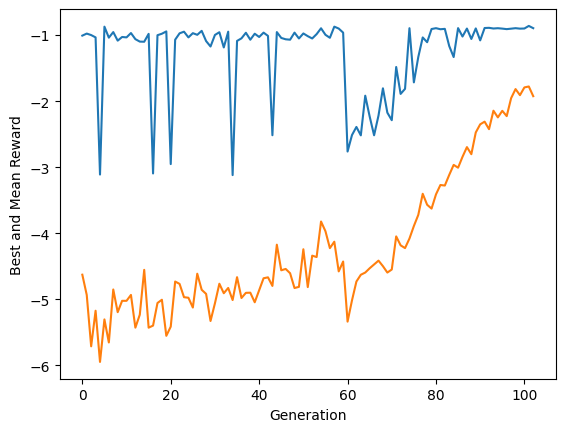

<Figure size 640x480 with 0 Axes>

In [ ]:
import numpy as np
import torch

from lib.velocity_field import *
from lib.shared_memory_utils import *
from lib.zermelo_env import *
from lib.algs_parallel import *

mp.set_start_method("spawn", force=True)

#VelField = VortexFlow()
#CFG = VORTEX_CONFIG

#VelField = SRFlow()
#CFG = SR_CONFIG

#VelField = TGFlow()
#CFG = TG_CONFIG

#best_policy, rewards, mean_rewards = train_ga(CFG, VelField, shared=False, generations=150, episodes=1)

#VelField = TurbFlow("./data/2d-turb-data.jld", steady=True)
#CFG = TURB_STEADY_P2

VelField = TurbFlow("./data/2d-turb-data.jld", steady=False)
CFG = TURB_TIME_P2

SharedVelField = create_shared_velocity_field(VelField)
best_policy, rewards, mean_rewards = train_ga(CFG, SharedVelField, shared=True, generations=150, episodes=4)
release_shared_velocity_field(SharedVelField)

print("Training Complete")
plot_rewards(rewards, mean_rewards, show_result=True)
plt.ioff()
plt.show()

## Optional fine-tuning using CMA-ES

In [ ]:
#SharedVelField = create_shared_velocity_field(VelField)
policy_tuned, rewards_tuned, mean_rewards_tuned = train_cma_es(CFG, VelField, shared=False, #SharedVelField, shared=True,
                                                               init_model = best_policy, generations=50, episodes=50)
#release_shared_velocity_field(SharedVelField)

print("Fine-Tuning Complete")
plot_rewards(rewards_tuned, mean_rewards_tuned, show_result=True)
plt.ioff()
plt.show()

# Model Evaluation

In [ ]:
import h5py

env = ZermeloEnv(CFG, VelField)
results = evaluate_policy(model=best_policy, env=env, n_eval=5000)

success_probability = np.mean([r["success"] for r in results])
mean_success_time = np.mean([r["time"] for r in results if r["success"]])

print(f"Success probability : {success_probability:.4f}")
print(f"Mean success time: {mean_success_time:.4f}")

track_opt = []

with h5py.File("./data/opt-control.jld2", "r") as f:
    x_opt = f["x_tp2"]  # x_v, x_sr, x_tg, x_sp1, x_sp2, x_tp1, x_tp2
    y_opt = f["y_tp2"]
    track_opt = np.stack((x_opt, y_opt), axis=1)

trajectories = [r["trajectory"] for r in results]
plot_trajectories(env, trajectories[0:10] + [track_opt], time=mean_success_time)

In [ ]:
p_sp1 = [1, 0.9840, 1, 1, 1, 1, 1, 1, 1, 1]
t_sp1 = [0.9139, 0.9085, 0.9064, 0.9070, 0.9049, 0.9011, 0.9080, 0.9040, 0.9055, 0.9055]

p_sp2 = [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
t_sp2 = [0.8850, 0.8867, 0.8838, 0.8919, 0.8912, 0.8793, 0.8921, 0.8864, 0.8819, 0.8790]

p_tp1 = [1, 1, 1, 1, 1, 1, 1, 1, 1, 0.9836]
t_tp1 = [0.7745, 0.7840, 0.7682, 0.7843, 0.7908, 0.7923, 0.7954, 0.7633, 0.7691, 0.7885]

p_tp2 = []
t_tp2 = []

# Histogram of arrival times 

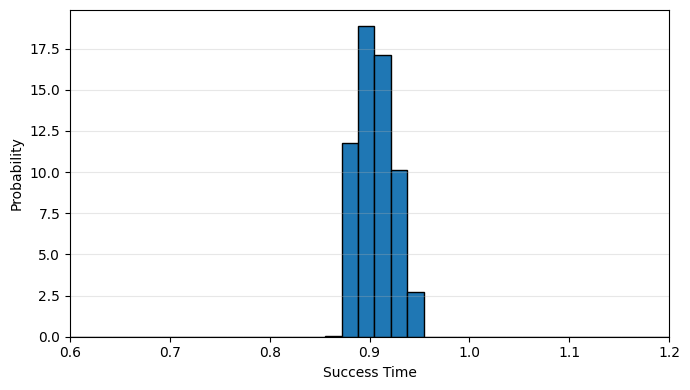

In [19]:
success_times = [r["time"] for r in results if r["success"]]

plt.figure(figsize=(7, 4))

plt.xlim(0.6, 1.2) 

bins = np.arange(0, env.T_max + env.Δt, 2*env.Δt)
plt.hist(success_times, bins=bins, edgecolor="black", density=True)

plt.xlabel("Success Time")
plt.ylabel("Probability")
#plt.title(f"Distribution of successful episode times (N={len(success_times)})")

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Save & Load Model

In [ ]:
torch.save(best_policy.state_dict(), "./saved_models/tp2.pth")

"""
env = ZermeloEnv(CFG, VelField)
obs_dim = env.observation_space.shape[0]
act_dim = env.action_space.shape[0]
best_policy = PolicyNet(obs_dim, act_dim)
best_policy.load_state_dict(torch.load("./saved_models/sp1.pth"))
"""